# SpinVibe Tutorial

## Running a Spin-Phonon Coupling Simulation

This tutorial demonstrates how to use SpinVibe to simulate spin-phonon coupling and calculate spin relaxation times (T₁).

## Executing the Simulation

In [38]:
!spinvibe input.json

Reading input parameters from: input.json
Running with MPI on rank 0
Initializing input files...
  spin_file: Cr_otolyl_4.h5
  phonon_file: phonon.h5
  d1_file: Cr_otolyl_4_d1.h5
  d2_file: d_16.h5
  g2_file: g_16.h5
  atoms_file: Sn_otolyl_4_atoms.h5
  indices_file: molecule_indices.h5
  mol_mass: mol_mass.h5
2026-01-21 16:33:43
---------------------------------------
|Start Spin-phonon coupling simulation|
---------------------------------------


Input Parameters
Magnetic field: [0.   0.   0.41]
S: 1
T: 20.0
Broadening: 1.0
Population type: pure
Polarization: [0 0 1]
Rotational matrix:
[[0 0 1]
 [1 0 0]
 [0 1 0]]


Spin Hamiltonian
[[-3.61376628e-01+0.00000000e+00j -2.91812008e-06+1.06333248e-05j
   5.11553213e-02-7.05205722e-06j]
 [-2.91812008e-06-1.06333248e-05j -3.41022461e-02+0.00000000e+00j
   2.91812008e-06-1.06333248e-05j]
 [ 5.11553213e-02+7.05205722e-06j  2.91812008e-06+1.06333248e-05j
   3.95478874e-01+0.00000000e+00j]]


Eigenvalues of the spin Hamiltonian
[-0.36481853 -0

## Understanding the Output

### 1. Input Parameters and System Setup

The code starts by reading configuration parameters from `input.json` and initializing the required input files:

```python
Input Parameters
================
Magnetic field: [0.   0.   0.41]
S: 1
T: 20.0
Broadening: 1.0
Population type: pure
Polarization: [0 0 1]
```

**Key parameters:**
- **Magnetic field**: Applied external field in Tesla (here, 0.41 T along the z-axis)
- **S**: Total spin quantum number (S=1 for this system)
- **T**: Temperature in Kelvin (20 K)
- **Broadening**: Energy broadening parameter for spectral functions (1.0 meV)
- **Polarization**: Initial spin polarization direction (z-axis)


### 2. Spin Hamiltonian Construction

The code constructs the spin Hamiltonian matrix from the input files, incorporating magnetic field effects from the Zeeman effect:


```python
Spin Hamiltonian

[[-3.61376628e-01+0.00000000e+00j -2.91812008e-06+1.06333248e-05j 5.11553213e-02-7.05205722e-06j]
 [-2.91812008e-06-1.06333248e-05j -3.41022461e-02+0.00000000e+00j 2.91812008e-06-1.06333248e-05j]
 [ 5.11553213e-02+7.05205722e-06j  2.91812008e-06+1.06333248e-05j 3.95478874e-01+0.00000000e+00j]]

```

The Hamiltonian is then diagonalized to obtain the energy eigenvalues:

```python
Eigenvalues of the spin Hamiltonian
[-0.36481853 -0.03410225  0.39892077]
```

These eigenvalues represent the energy levels of the spin system and can be directly compared to experimental measurements from techniques such as electron paramagnetic resonance (EPR) or inelastic neutron scattering.

The simulation initializes the spin density matrix according to the specified input:

```python
Initial spin population:
[[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j]]
```

In this example, the initial spin density matrix represents a pure state with the spin fully polarized along the z-axis, which corresponds to common experimental setups such as optical pumping.


### 3. Redfield Superoperator Construction

The core of the simulation involves constructing the Redfield superoperator, which describes the dynamics of the spin density matrix under the influence of spin-phonon coupling. The implementation includes:


#### Linear Coupling (R1 tensor)

The first-order spin-phonon coupling term, computed from the first derivative of the spin Hamiltonian with respect to phonon coordinates:

```python
Initializing R1 tensor (Linear coupling)
Number of tasks per process: 342
Eigenvalues of the R1 matrix
[-4.32928403e+05+8.87601118e-12j -3.73096574e+05+5.37370454e-12j
 -2.51849298e+05-2.57225740e-11j -2.08380892e+05-7.72032805e-12j
 -2.07571515e-10+8.55220869e-12j -3.67404673e+04-1.05524586e-12j
 -5.45373231e+04-1.53666756e-11j -8.53366127e+04+2.11214278e-11j
 -9.73847207e+04+1.68554078e-11j]
```

#### Quadratic Coupling (R2 tensor)

The second-order spin-phonon coupling term, computed from the second derivative of the spin Hamiltonian:

```python
Initializing R2 tensor (Quadratic coupling)
Number of tasks per process: 58653
Eigenvalues of the R2 matrix
[-2.08534136e+08+1.57641106e-08j -2.00838125e+08+2.60960742e-09j
 -1.87097051e+08+8.08624383e-09j -1.84273465e+08+8.26727677e-09j
 -1.40143977e+07+9.57071339e-09j -1.23104329e+07-3.87725813e-09j
  8.30111004e-07-2.61653084e-09j -3.21323375e+06-2.06520018e-09j
 -5.74226878e+06-1.11753300e-08j]
```

#### Validation Check: Redfield Eigenvalues

**Sanity check:** The eigenvalues of the complete Redfield superoperator must satisfy:
- One eigenvalue must be exactly zero (corresponding to equilibrium)
- All other eigenvalues must have negative real parts (ensuring decay to equilibrium)

```python
Eigenvalues of the Redfield matrix
[-2.08897837e+08-1.66776197e-08j -2.01136734e+08-1.18070589e-08j
 -1.87383028e+08-1.17840931e-08j -1.84493332e+08+7.60240576e-09j
  8.20916955e-07-6.23446020e-09j -1.41058892e+07+1.07293940e-08j
 -1.24205488e+07-1.17568006e-08j -3.25784591e+06+1.22658682e-09j
 -5.86814915e+06+2.49648097e-09j]
```

Note the eigenvalue `8.20916955e-07`, which is effectively zero within numerical precision. If this condition is violated, the simulation results are unphysical and should not be trusted.

After the construction of the linear, quadratic and total Redfield operators, the code performs a time evolution of the density matrix to separate the linear and quadratic contribution.

### 4. Time Evolution and Spin Relaxation

The code then propagates the density matrix in time using the Redfield equation and tracks the magnetization decay along the measurement direction:

```python
Equilibrium M_parallel: 0.0005687673121864239
Initial Magnetization: 1.0000
Fitted Equilibrium Magnetization: 0.0006
R² = 0.9610
```

#### T₁ Extraction

The spin-lattice relaxation time (T₁) is extracted by fitting the magnetization decay to an exponential function:

M(t) = M_eq + (M_0 - M_eq) × exp(-t/T₁)

```python
T1 from magnetization decay
T1 =  6.248628897780945e-08 s
T1_err =  8.261351830318641e-10 s
```

**Important:** The fitting error `T1_err` provides a measure of the quality of the exponential fit. A large error relative to T₁ (e.g., T1_err/T1 > 0.1) indicates potential issues such as:
- Insufficient simulation time
- Poor time resolution
- Inadequate convergence of the Redfield calculation
- Non-exponential relaxation dynamics

### 5. Data Storage and Analysis

All simulation results are saved to an HDF5 file for further analysis:

```python
Data has been saved to Spin_phonon_20K_1.0.h5
```

The output file contains:
- Time-evolved density matrices
- Magnetization as a function of time
- Complete Redfield superoperator
- Spin-phonon coupling in phonon basis
- Spin-phonon coupling in atomic basis

##### Plotting the Time Evolution of the Spin Density

You can visualize how the spin populations evolve over time:

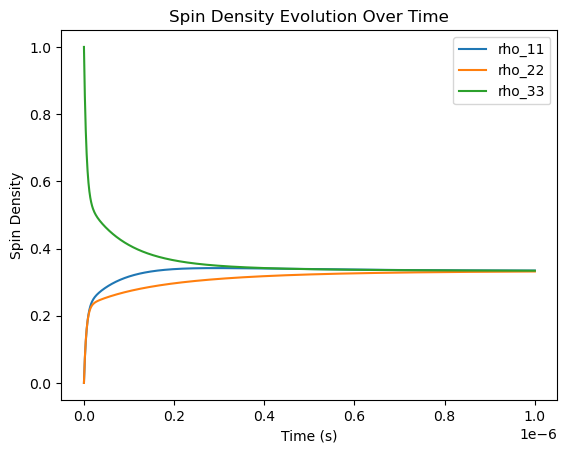

In [40]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt

with h5.File('Spin_phonon_20K_1.0.h5', 'r') as data:
    tlist = data['input/tlist'][:]
    rho_t = data['output/rho_t'][:]

plt.plot(tlist, rho_t[0, 0,:].real, label='rho_11')
plt.plot(tlist, rho_t[1, 1,:].real, label='rho_22')
plt.plot(tlist, rho_t[2, 2,:].real, label='rho_33')

plt.xlabel('Time (s)')
plt.ylabel('Spin Density')
plt.title('Spin Density Evolution Over Time')

plt.legend()

plt.show()

##### Plotting the Magnetization Decay

The magnetization decay along the measurement direction can be visualized to see the exponential relaxation:


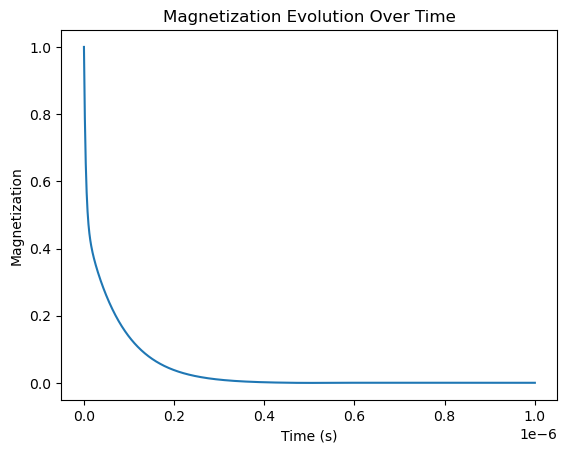

In [41]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt

with h5.File('Spin_phonon_20K_1.0.h5', 'r') as data:
    tlist = data['input/tlist'][:]
    M = data['output/M'][:]

plt.plot(tlist, M, label='M')

plt.xlabel('Time (s)')
plt.ylabel('Magnetization')
plt.title('Magnetization Evolution Over Time')

plt.show()

##### Analyzing Spin-Phonon Coupling Strengths

You can examine which atoms or phonon modes contribute most strongly to spin relaxation:

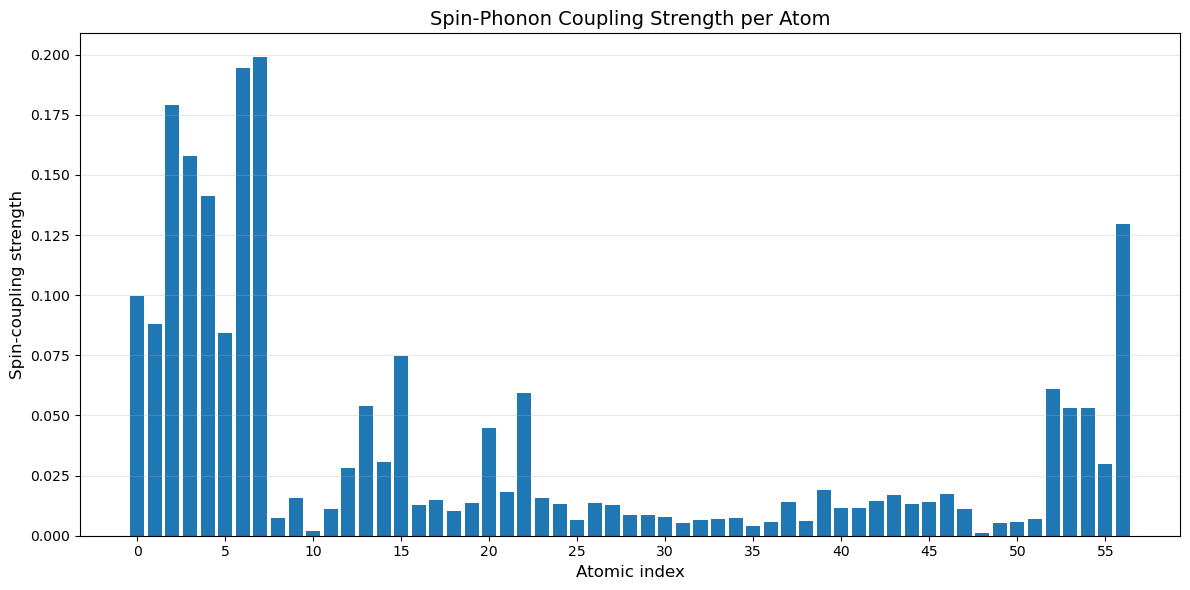

In [42]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt

with h5.File('Spin_phonon_20K_1.0.h5', 'r') as data:
    dH_dx = data['output/dH_dx'][:]

data = np.abs(dH_dx[:,0,0,0])

plt.figure(figsize=(12, 6))
plt.bar(range(57), data)
plt.title('Spin-Phonon Coupling Strength per Atom', fontsize=14)
plt.xlabel('Atomic index', fontsize=12)
plt.ylabel('Spin-coupling strength', fontsize=12)
plt.xticks(range(0, 57, 5))  # Show every 5th tick to avoid crowding
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



The atomic index analysis demonstrates that the spin-phonon coupling is dominated by modes involving motion of the Cr atom (index 56) and the three closest C atoms of each ligand attached to the metal center (indices 0-7 and 52-55). This indicates that local vibrational modes in the first coordination sphere are the primary contributors to spin relaxation, consistent with the expected localization of magnetic excitations near the metal center.

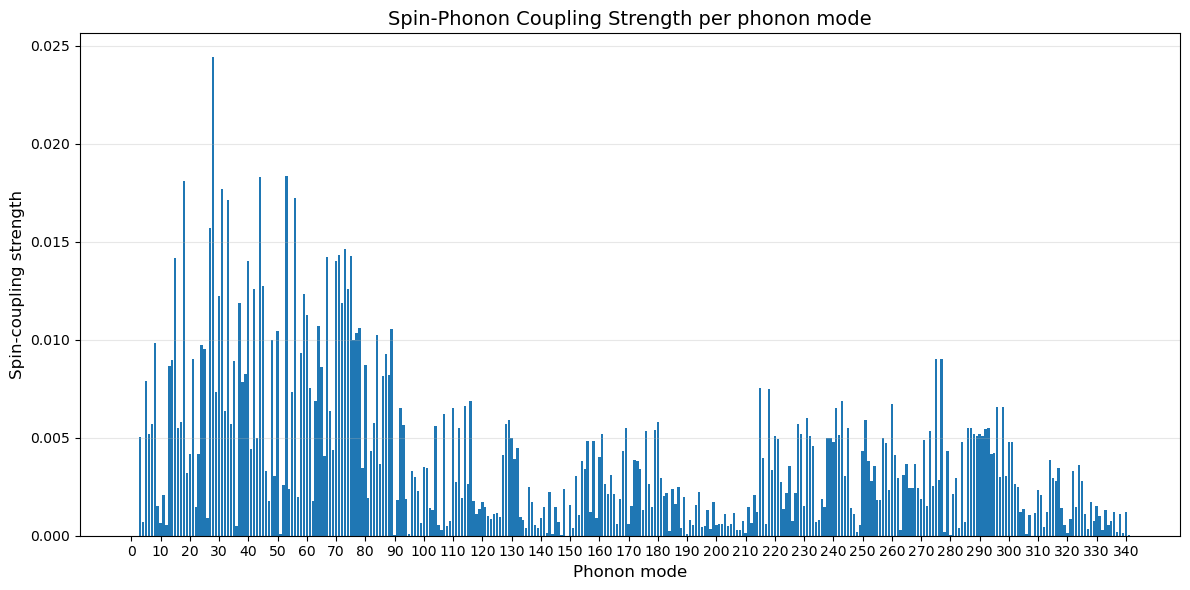

In [43]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt

with h5.File('Spin_phonon_20K_1.0.h5', 'r') as data:
    dH_dq = data['output/dH_dq'][:]

data = np.abs(dH_dq[0,:,0,0])

plt.figure(figsize=(12, 6))
plt.bar(range(342), data)
plt.title('Spin-Phonon Coupling Strength per phonon mode', fontsize=14)
plt.xlabel('Phonon mode', fontsize=12)
plt.ylabel('Spin-coupling strength', fontsize=12)
plt.xticks(range(0, 342, 10))  # Show every 5th tick to avoid crowding
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In the phonon basis, the dominant phonon modes are those with lower indices, which correspond to lower-frequency vibrations involving the heavier Cr metal center. This behavior is physically consistent, as heavier atoms produce lower-frequency phonon modes due to their larger mass.